# Replacement-Dynamics Model with Explicit Entries and Disposals

This notebook is a stricter version of the replacement-dynamics model.

Instead of using a single **average net fleet change** assumption, it models the two fleet flows separately:

1. **entries** (`Entrant` or `Neuf`),
2. **disposals** (`Sortant`).

That means the future fleet is built year by year from:

- forecasted **entry volumes**,
- forecasted **disposal volumes**,
- forecasted **entry mix by vehicle type**,
- forecasted **disposal mix by vehicle type**.

This structure is more realistic because it matches the mechanism of fleet turnover:

- the **sales mix** can change quickly,
- the **disposal mix** can also evolve,
- but the **fleet composition** changes gradually through replacement.

## Core modeling logic

For each future year `t`:

- forecast total entries `E_t`,
- forecast total disposals `X_t`,
- forecast entry share by type `s_entry_(k,t)`,
- forecast disposal share by type `s_exit_(k,t)`,
- compute additions and removals by type:

`add_(k,t) = E_t * s_entry_(k,t)`

`remove_(k,t) = X_t * s_exit_(k,t)`

- update the fleet counts:

`fleet_(k,t) = fleet_(k,t-1) + add_(k,t) - remove_(k,t)`

This avoids exponential fleet growth and does not rely on a single average net-growth assumption.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PROJECT_DIR = Path('/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model')
CACHE_DIR = PROJECT_DIR / '.cache'

FLEET_COUNTS_CACHE = CACHE_DIR / 'saq_vehicle_counts.pkl'
ENTRY_COUNTS_CACHE = CACHE_DIR / 'saq_entry_counts.pkl'
ENTRY_FULL_CACHE = CACHE_DIR / 'saq_entry_full.pkl'

fleet_counts = pd.read_pickle(FLEET_COUNTS_CACHE)
entry_counts = pd.read_pickle(ENTRY_COUNTS_CACHE)
entry_full = pd.read_pickle(ENTRY_FULL_CACHE)

fleet_counts.head()

,fsa,AnneeSAAQ,vehicle_type,count
0,G0A,2013,electric,10
1,G0A,2013,hev_sedan,144
2,G0A,2013,hev_suv,38
3,G0A,2013,ice_sedan,28633
4,G0A,2013,ice_suv,18244


## Settings

These parameters control the projection.

Important choices:

- `ENTRY_FLAG`: which variable is used to represent new vehicles entering the fleet.
- `FORECAST_END_YEAR`: final projection year.
- `USE_RECENT_YEARS_ONLY`: if `True`, averages and trends use only more recent years.
- `FLOW_RATE_CLIP`: caps extreme entry and exit rates.
- `SHARE_ADOPTION_CLIP`: caps extreme year-over-year changes in entry and disposal shares.
- `FLOW_MODEL`: choose how future entry/exit rates are projected.

Recommended default:
- use `Entrant` for entries,
- use `Sortant` for exits,
- use `linear` flow trends if you want explicit year-by-year evolution,
- use `average` if you want a more conservative proof of concept.

In [2]:
ENTRY_FLAG = 'Entrant'
EXIT_FLAG = 'Sortant'
FORECAST_END_YEAR = 2035
USE_RECENT_YEARS_ONLY = False
RECENT_YEAR_START = 2017
FLOW_MODEL = 'linear'  # 'linear' or 'average'
FLOW_RATE_CLIP = (0.0, 0.20)
SHARE_ADOPTION_CLIP = (-0.75, 1.50)

vehicle_cols = ['electric', 'hev_sedan', 'hev_suv', 'ice_sedan', 'ice_suv', 'ice_van/pickup']

## Step 1: Historical Fleet, Entries, and Disposals

We first build three historical tables by year:

- fleet counts by vehicle type,
- entries by vehicle type,
- disposals by vehicle type.

This separates inflow and outflow directly from the SAAQ data.

In [3]:
fleet_pivot = (
    fleet_counts.pivot_table(
        index='AnneeSAAQ',
        columns='vehicle_type',
        values='count',
        aggfunc='sum',
        fill_value=0,
    )
    .reindex(columns=vehicle_cols, fill_value=0)
    .sort_index()
)
fleet_pivot['total_vehicles'] = fleet_pivot.sum(axis=1)

entry_pivot = (
    entry_counts.pivot_table(
        index='AnneeSAAQ',
        columns='vehicle_type',
        values=ENTRY_FLAG,
        aggfunc='sum',
        fill_value=0,
    )
    .reindex(columns=vehicle_cols, fill_value=0)
    .sort_index()
)
entry_pivot['total_entries'] = entry_pivot.sum(axis=1)

exit_pivot = (
    entry_full.pivot_table(
        index='AnneeSAAQ',
        columns='vehicle_type',
        values=EXIT_FLAG,
        aggfunc='sum',
        fill_value=0,
    )
    .reindex(columns=vehicle_cols, fill_value=0)
    .sort_index()
)
exit_pivot['total_exits'] = exit_pivot.sum(axis=1)

pd.DataFrame({
    'year': fleet_pivot.index,
    'total_vehicles': fleet_pivot['total_vehicles'].values,
    'total_entries': entry_pivot['total_entries'].reindex(fleet_pivot.index).values,
    'total_exits': exit_pivot['total_exits'].reindex(fleet_pivot.index).values,
}).head(10)

,year,total_vehicles,total_entries,total_exits
0,2013,4276020,355757,583434
1,2014,4335872,355998,625644
2,2015,4402825,367078,638134
3,2016,4482995,364228,685723
4,2017,4568007,375681,746009
5,2018,4592553,367052,738674
6,2019,4642003,357698,742505
7,2020,4728601,317739,892332


## Step 2: Historical Entry and Disposal Shares by Vehicle Type

Now we compute the composition of the inflow and outflow:

- entry share by type,
- disposal share by type.

These two mixes play different roles:

- **entry share** says what technologies are being added,
- **disposal share** says what technologies are leaving the fleet.

In [4]:
entry_share_hist = entry_pivot[vehicle_cols].div(entry_pivot['total_entries'].replace(0, np.nan), axis=0).fillna(0)
exit_share_hist = exit_pivot[vehicle_cols].div(exit_pivot['total_exits'].replace(0, np.nan), axis=0).fillna(0)

entry_share_hist.head()

vehicle_type,electric,hev_sedan,hev_suv,ice_sedan,ice_suv,ice_van/pickup
AnneeSAAQ,,,,,,
2013,0.001130,0.012233,0.002170,0.555115,0.361320,0.068032
2014,0.002573,0.013961,0.002545,0.535750,0.377395,0.067776
2015,0.003648,0.010883,0.002555,0.501907,0.398370,0.082636
2016,0.004580,0.013579,0.006828,0.448346,0.422134,0.104533
2017,0.008763,0.015851,0.008127,0.419497,0.441662,0.106101


In [5]:
exit_share_hist.head()

vehicle_type,electric,hev_sedan,hev_suv,ice_sedan,ice_suv,ice_van/pickup
AnneeSAAQ,,,,,,
2013,0.000007,0.000723,0.000257,0.644107,0.241095,0.113811
2014,0.000030,0.001002,0.000249,0.634076,0.241166,0.123476
2015,0.000050,0.001445,0.000340,0.624403,0.245787,0.127975
2016,0.000147,0.001452,0.000419,0.620353,0.253197,0.124432
2017,0.000263,0.001567,0.000491,0.605928,0.267308,0.124444


## Step 3: Historical Adoption Rates for Entry and Disposal Shares

To project future composition, we compute year-over-year changes in both share systems:

- entry-share adoption rates,
- disposal-share adoption rates.

To avoid unstable values:

- `inf`, `-inf`, and missing values become `0`,
- extreme rates are clipped.

This is especially important when a vehicle type starts from zero in one year.

In [6]:
entry_share_adoption = entry_share_hist.pct_change().replace([np.inf, -np.inf], 0).fillna(0)
exit_share_adoption = exit_share_hist.pct_change().replace([np.inf, -np.inf], 0).fillna(0)

entry_share_adoption = entry_share_adoption.clip(lower=SHARE_ADOPTION_CLIP[0], upper=SHARE_ADOPTION_CLIP[1])
exit_share_adoption = exit_share_adoption.clip(lower=SHARE_ADOPTION_CLIP[0], upper=SHARE_ADOPTION_CLIP[1])

entry_share_adoption.head()

vehicle_type,electric,hev_sedan,hev_suv,ice_sedan,ice_suv,ice_van/pickup
AnneeSAAQ,,,,,,
2013,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2014,1.277064,0.141231,0.172781,-0.034884,0.044492,-0.003774
2015,0.417667,-0.220440,0.004070,-0.063170,0.055578,0.219263
2016,0.255453,0.247735,1.500000,-0.106716,0.059652,0.264981
2017,0.913453,0.167298,0.190159,-0.064345,0.046260,0.014993


## Step 4: Historical Entry and Exit Rates Relative to Fleet Size

For the total flow volumes, we use rates relative to the fleet size:

`entry_rate_t = total_entries_t / total_fleet_(t-1)`

`exit_rate_t = total_exits_t / total_fleet_(t-1)`

This is better than forecasting raw totals alone because it ties flows to the size of the fleet being replaced.

In [7]:
flow_rates = pd.DataFrame(index=fleet_pivot.index)
flow_rates['fleet_prev_year'] = fleet_pivot['total_vehicles'].shift(1)
flow_rates['total_entries'] = entry_pivot['total_entries'].reindex(flow_rates.index)
flow_rates['total_exits'] = exit_pivot['total_exits'].reindex(flow_rates.index)
flow_rates['entry_rate'] = (flow_rates['total_entries'] / flow_rates['fleet_prev_year']).replace([np.inf, -np.inf], np.nan)
flow_rates['exit_rate'] = (flow_rates['total_exits'] / flow_rates['fleet_prev_year']).replace([np.inf, -np.inf], np.nan)
flow_rates

,fleet_prev_year,total_entries,total_exits,entry_rate,exit_rate
AnneeSAAQ,,,,,
2013,NaN,355757,583434,NaN,NaN
2014,4276020.0,355998,625644,0.083255,0.146315
2015,4335872.0,367078,638134,0.084661,0.147175
2016,4402825.0,364228,685723,0.082726,0.155746
2017,4482995.0,375681,746009,0.083801,0.166409
2018,4568007.0,367052,738674,0.080353,0.161706
2019,4592553.0,357698,742505,0.077887,0.161676
2020,4642003.0,317739,892332,0.068449,0.192230


## Step 5: Estimate Future Entry and Disposal Flow Rates

We forecast future entry and disposal rates separately.

Two options are available:

- `average`: use the historical average rate,
- `linear`: fit a linear time trend to the historical rates.

The default is `linear`, because it gives explicit year-by-year entry and disposal volumes rather than collapsing them into one average net-change assumption.

In [8]:
flow_source = flow_rates.dropna().copy()
if USE_RECENT_YEARS_ONLY:
    flow_source = flow_source[flow_source.index >= RECENT_YEAR_START]

share_entry_source = entry_share_adoption.copy()
share_exit_source = exit_share_adoption.copy()
if USE_RECENT_YEARS_ONLY:
    share_entry_source = share_entry_source[share_entry_source.index >= RECENT_YEAR_START]
    share_exit_source = share_exit_source[share_exit_source.index >= RECENT_YEAR_START]

avg_entry_rate = float(flow_source['entry_rate'].mean())
avg_exit_rate = float(flow_source['exit_rate'].mean())
avg_entry_share_adoption = share_entry_source.mean().reindex(vehicle_cols).fillna(0)
avg_exit_share_adoption = share_exit_source.mean().reindex(vehicle_cols).fillna(0)

flow_summary = pd.DataFrame({
    'metric': ['avg_entry_rate', 'avg_exit_rate'],
    'value': [avg_entry_rate, avg_exit_rate],
})
flow_summary

,metric,value
0,avg_entry_rate,0.080162
1,avg_exit_rate,0.161608


In [9]:
def fit_linear_rate_projection(series, future_years, clip_bounds):
    hist = series.dropna().copy()
    if len(hist) < 2:
        return pd.Series({year: float(hist.iloc[-1]) if len(hist) else 0.0 for year in future_years})

    x = hist.index.to_numpy(dtype=float)
    y = hist.to_numpy(dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    pred = pd.Series({year: intercept + slope * year for year in future_years}, dtype=float)
    return pred.clip(lower=clip_bounds[0], upper=clip_bounds[1])

## Step 6: Forecast Future Entry and Disposal Shares

We project the composition of entries and disposals separately.

This means the model can capture both:

- cleaner technologies entering faster,
- older technologies leaving faster.

In [10]:
last_observed_year = int(fleet_pivot.index.max())
future_years = list(range(last_observed_year + 1, FORECAST_END_YEAR + 1))

entry_share_future = entry_share_hist.copy()
exit_share_future = exit_share_hist.copy()

current_entry_share = entry_share_future.loc[last_observed_year, vehicle_cols].astype(float).copy()
current_exit_share = exit_share_future.loc[last_observed_year, vehicle_cols].astype(float).copy()

if current_entry_share.sum() <= 0:
    current_entry_share[:] = 1 / len(vehicle_cols)
else:
    current_entry_share = current_entry_share / current_entry_share.sum()

if current_exit_share.sum() <= 0:
    current_exit_share[:] = 1 / len(vehicle_cols)
else:
    current_exit_share = current_exit_share / current_exit_share.sum()

for year in future_years:
    next_entry_share = current_entry_share * (1 + avg_entry_share_adoption)
    next_exit_share = current_exit_share * (1 + avg_exit_share_adoption)

    next_entry_share = next_entry_share.clip(lower=0)
    next_exit_share = next_exit_share.clip(lower=0)

    if next_entry_share.sum() > 0:
        next_entry_share = next_entry_share / next_entry_share.sum()
    else:
        next_entry_share = current_entry_share.copy()

    if next_exit_share.sum() > 0:
        next_exit_share = next_exit_share / next_exit_share.sum()
    else:
        next_exit_share = current_exit_share.copy()

    entry_share_future.loc[year, vehicle_cols] = next_entry_share
    exit_share_future.loc[year, vehicle_cols] = next_exit_share

    current_entry_share = next_entry_share.copy()
    current_exit_share = next_exit_share.copy()

entry_share_future.tail(10)

vehicle_type,electric,hev_sedan,hev_suv,ice_sedan,ice_suv,ice_van/pickup
AnneeSAAQ,,,,,,
2026,0.438443,0.018406,0.092036,0.079282,0.308186,0.063647
2027,0.543220,0.015130,0.096863,0.054431,0.240249,0.050107
2028,0.640059,0.011828,0.096948,0.035538,0.178111,0.037515
2029,0.722531,0.008859,0.092964,0.022230,0.126507,0.026910
2030,0.788453,0.006414,0.086173,0.013442,0.086860,0.018659
2031,0.838901,0.004528,0.077883,0.007925,0.058148,0.012615
2032,0.876542,0.003139,0.069127,0.004588,0.038228,0.008375
2033,0.904340,0.002148,0.060582,0.002623,0.024816,0.005491
2034,0.924888,0.001458,0.052631,0.001487,0.015969,0.003568


## Step 7: Forecast Year-by-Year Entry and Disposal Volumes

Now we project the total inflow and outflow explicitly year by year.

If `FLOW_MODEL = 'linear'`:
- entry rates and exit rates evolve with a linear time trend.

If `FLOW_MODEL = 'average'`:
- entry rates and exit rates stay fixed at their historical average.

Future total volumes are computed as rates multiplied by the current fleet size.

In [11]:
if FLOW_MODEL == 'linear':
    future_entry_rate = fit_linear_rate_projection(flow_source['entry_rate'], future_years, FLOW_RATE_CLIP)
    future_exit_rate = fit_linear_rate_projection(flow_source['exit_rate'], future_years, FLOW_RATE_CLIP)
else:
    future_entry_rate = pd.Series(avg_entry_rate, index=future_years, dtype=float).clip(lower=FLOW_RATE_CLIP[0], upper=FLOW_RATE_CLIP[1])
    future_exit_rate = pd.Series(avg_exit_rate, index=future_years, dtype=float).clip(lower=FLOW_RATE_CLIP[0], upper=FLOW_RATE_CLIP[1])

flow_forecast = pd.DataFrame({
    'entry_rate': future_entry_rate,
    'exit_rate': future_exit_rate,
})
flow_forecast

,entry_rate,exit_rate
2021,0.071542,0.186280
2022,0.069387,0.192449
2023,0.067232,0.198617
2024,0.065077,0.200000
2025,0.062922,0.200000
2026,0.060767,0.200000
2027,0.058612,0.200000
2028,0.056457,0.200000
2029,0.054302,0.200000
2030,0.052147,0.200000


## Step 8: Rebuild the Fleet Using Explicit Entries and Disposals

This is the main forecasting step.

For each future year:

1. use the projected total fleet from the previous year,
2. compute entry volume from the forecast entry rate,
3. compute disposal volume from the forecast exit rate,
4. allocate entries using the projected entry share,
5. allocate disposals using the projected disposal share,
6. update the fleet counts.

This is the key difference from the previous notebook:

- we are **not** using `entries - average_net_change` to infer exits,
- we are forecasting entries and disposals separately.

In [12]:
projected_counts = fleet_pivot.copy()
current_counts = projected_counts.loc[last_observed_year, vehicle_cols].astype(float).copy()
projection_rows = []

for year in future_years:
    current_total = float(current_counts.sum())

    entry_rate = float(flow_forecast.loc[year, 'entry_rate'])
    exit_rate = float(flow_forecast.loc[year, 'exit_rate'])

    entries = current_total * entry_rate
    exits = current_total * exit_rate

    entry_mix = entry_share_future.loc[year, vehicle_cols].astype(float)
    exit_mix = exit_share_future.loc[year, vehicle_cols].astype(float)

    additions = entries * entry_mix
    removals = exits * exit_mix

    next_counts = (current_counts + additions - removals).clip(lower=0)
    next_total = float(next_counts.sum())

    projected_counts.loc[year, vehicle_cols] = next_counts
    projected_counts.loc[year, 'total_vehicles'] = next_total

    projection_rows.append({
        'year': year,
        'fleet_start': current_total,
        'entry_rate': entry_rate,
        'exit_rate': exit_rate,
        'entries': entries,
        'exits': exits,
        'net_change': entries - exits,
        'fleet_end': next_total,
    })

    current_counts = next_counts.copy()

projection_summary = pd.DataFrame(projection_rows)
projected_market_share = projected_counts[vehicle_cols].div(projected_counts[vehicle_cols].sum(axis=1), axis=0).fillna(0)
projection_summary.head()

,year,fleet_start,entry_rate,exit_rate,entries,exits,net_change,fleet_end
0,2021,4.728601e+06,0.071542,0.186280,338291.843849,880846.066605,-542554.222757,4.186047e+06
1,2022,4.186047e+06,0.069387,0.192449,290455.833566,805598.758072,-515142.924506,3.670904e+06
2,2023,3.670904e+06,0.067232,0.198617,246801.104805,729102.733776,-482301.628971,3.188602e+06
3,2024,3.188602e+06,0.065077,0.200000,207503.812679,637720.444753,-430216.632074,2.758386e+06
4,2025,2.758386e+06,0.062922,0.200000,173562.489071,551677.118338,-378114.629267,2.380271e+06


## Main Tables

These tables summarize:

- projected entry and disposal volumes,
- projected fleet counts,
- projected fleet market share.

In [13]:
projection_summary

,year,fleet_start,entry_rate,exit_rate,entries,exits,net_change,fleet_end
0,2021,4.728601e+06,0.071542,0.186280,338291.843849,880846.066605,-542554.222757,4.186047e+06
1,2022,4.186047e+06,0.069387,0.192449,290455.833566,805598.758072,-515142.924506,3.670904e+06
2,2023,3.670904e+06,0.067232,0.198617,246801.104805,729102.733776,-482301.628971,3.188602e+06
3,2024,3.188602e+06,0.065077,0.200000,207503.812679,637720.444753,-430216.632074,2.758386e+06
4,2025,2.758386e+06,0.062922,0.200000,173562.489071,551677.118338,-378114.629267,2.380271e+06
5,2026,2.380271e+06,0.060767,0.200000,144641.442960,476054.192485,-331412.749525,2.048858e+06
6,2027,2.048858e+06,0.058612,0.200000,120087.328896,409771.642580,-289684.313684,1.784603e+06
7,2028,1.784603e+06,0.056457,0.200000,100753.106002,356920.670874,-256167.564872,1.558956e+06
8,2029,1.558956e+06,0.054302,0.200000,84654.278769,311791.250829,-227136.972060,1.353811e+06
9,2030,1.353811e+06,0.052147,0.200000,70597.089263,270762.219727,-200165.130464,1.167829e+06


In [14]:
projected_counts.tail(15)

vehicle_type,electric,hev_sedan,hev_suv,ice_sedan,ice_suv,ice_van/pickup,total_vehicles
AnneeSAAQ,,,,,,,
2021,64375.463793,61190.308691,40631.580280,1.890934e+06,1.809777e+06,319139.279074,4.186047e+06
2022,91068.626299,63541.671101,51553.621153,1.540615e+06,1.678024e+06,246100.571218,3.670904e+06
2023,122528.041006,64279.908541,63229.357916,1.223750e+06,1.537526e+06,177289.082939,3.188602e+06
2024,156364.093821,63504.779233,75075.008014,9.504888e+05,1.397670e+06,115282.657836,2.758386e+06
2025,187783.248273,61358.573308,86378.075680,7.210583e+05,1.263100e+06,60592.393349,2.380271e+06
2026,209132.649512,58084.748607,96432.199208,5.335875e+05,1.138143e+06,13478.481871,2.048858e+06
2027,210729.845191,54080.316011,104743.951550,3.867219e+05,1.028327e+06,0.000000,1.784603e+06
2028,183078.328320,49807.784822,111273.151501,2.770827e+05,9.377142e+05,0.000000,1.558956e+06
2029,120607.262598,45804.404249,116215.321874,2.015227e+05,8.696614e+05,0.000000,1.353811e+06


In [15]:
projected_market_share.tail(15)

vehicle_type,electric,hev_sedan,hev_suv,ice_sedan,ice_suv,ice_van/pickup
AnneeSAAQ,,,,,,
2021,0.015379,0.014618,0.009706,0.451723,0.432335,0.076239
2022,0.024808,0.017310,0.014044,0.419683,0.457115,0.067041
2023,0.038427,0.020159,0.019830,0.383789,0.482194,0.055601
2024,0.056687,0.023022,0.027217,0.344582,0.506699,0.041794
2025,0.078892,0.025778,0.036289,0.302931,0.530654,0.025456
2026,0.102073,0.028350,0.047066,0.260432,0.555501,0.006579
2027,0.118082,0.030304,0.058693,0.216699,0.576222,0.000000
2028,0.117436,0.031949,0.071377,0.177736,0.601501,0.000000
2029,0.089087,0.033834,0.085843,0.148856,0.642380,0.000000


## Plot 1: Historical and Forecast Entry / Disposal Volumes

This figure shows the key change relative to the earlier model: entries and exits are forecast separately year by year.

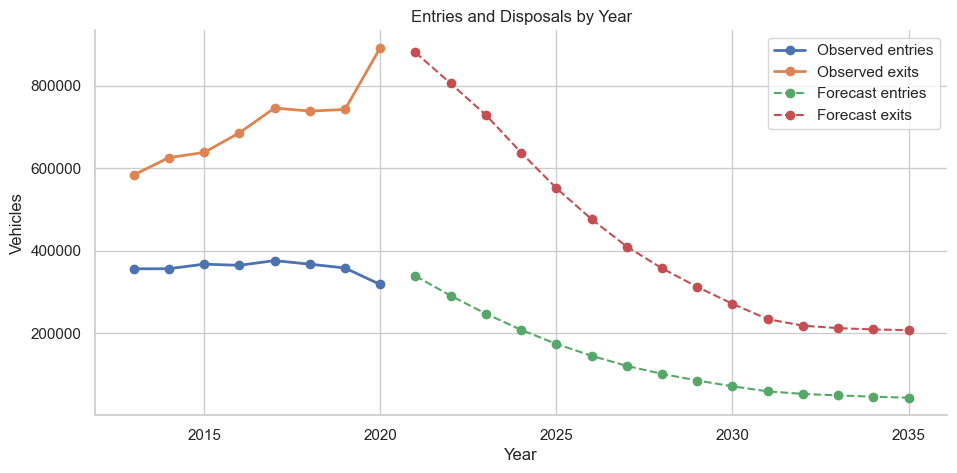

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))
flow_rates['total_entries'].plot(ax=ax, marker='o', linewidth=2, label='Observed entries')
flow_rates['total_exits'].plot(ax=ax, marker='o', linewidth=2, label='Observed exits')
projection_summary.set_index('year')['entries'].plot(ax=ax, marker='o', linestyle='--', label='Forecast entries')
projection_summary.set_index('year')['exits'].plot(ax=ax, marker='o', linestyle='--', label='Forecast exits')
ax.set_title('Entries and Disposals by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Vehicles')
ax.legend()
plt.show()

## Plot 2: Total Fleet Size

If the entry and exit rates remain close, the total fleet remains relatively stable.

If exits exceed entries, the fleet shrinks.

If entries exceed exits, the fleet grows.

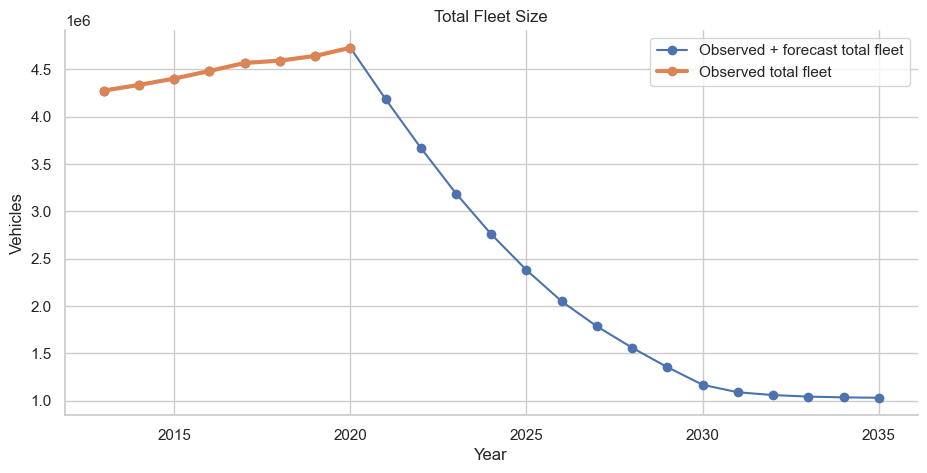

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))
projected_counts['total_vehicles'].plot(ax=ax, marker='o', label='Observed + forecast total fleet')
fleet_pivot['total_vehicles'].plot(ax=ax, marker='o', linewidth=3, label='Observed total fleet')
ax.set_title('Total Fleet Size')
ax.set_xlabel('Year')
ax.set_ylabel('Vehicles')
ax.legend()
plt.show()

## Plot 3: Entry and Disposal Share by Vehicle Type

These plots show how the composition of inflow and outflow evolves separately.

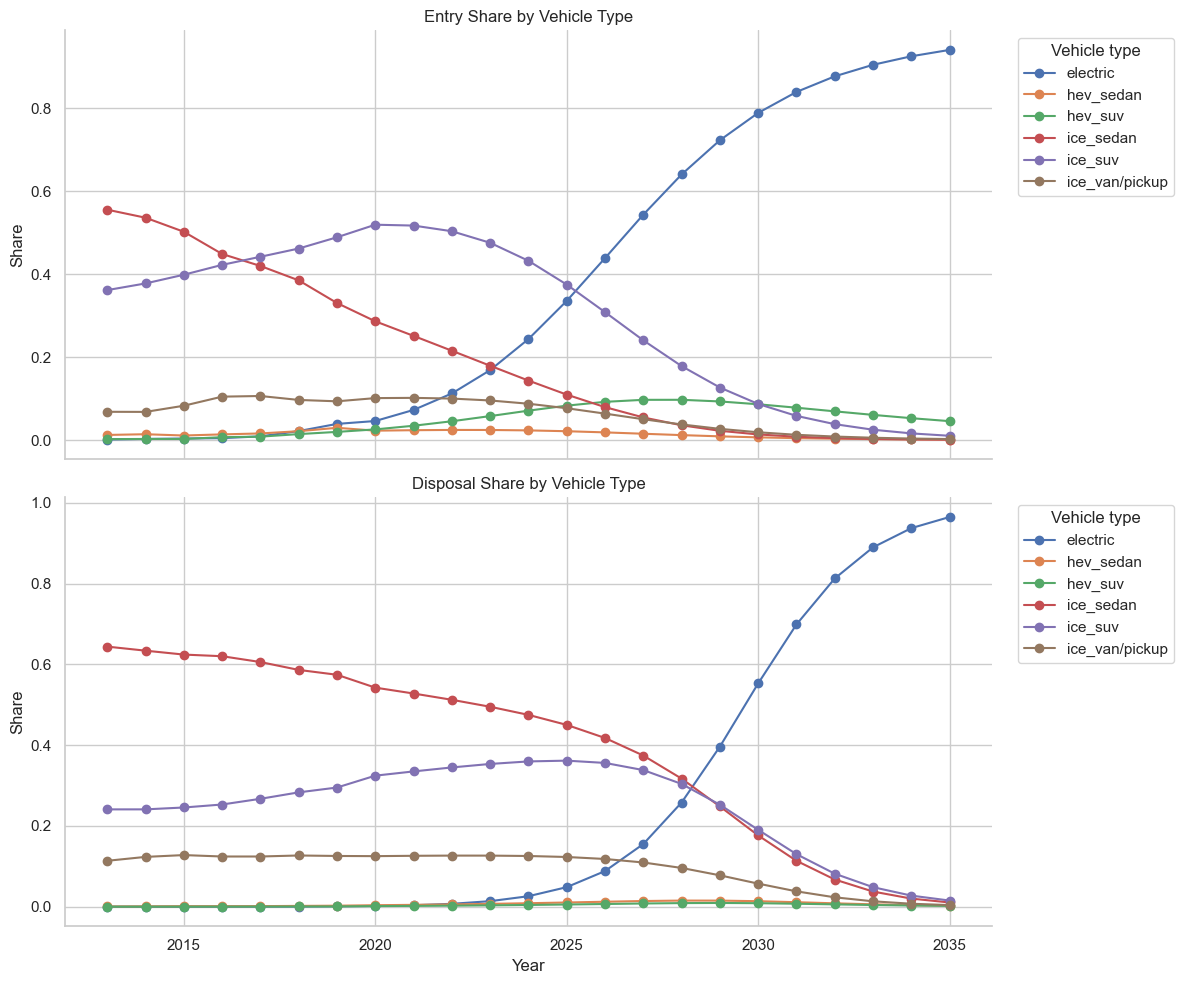

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
entry_share_future[vehicle_cols].plot(ax=axes[0], marker='o')
axes[0].set_title('Entry Share by Vehicle Type')
axes[0].set_ylabel('Share')
axes[0].legend(title='Vehicle type', bbox_to_anchor=(1.02, 1), loc='upper left')

exit_share_future[vehicle_cols].plot(ax=axes[1], marker='o')
axes[1].set_title('Disposal Share by Vehicle Type')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Share')
axes[1].legend(title='Vehicle type', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Plot 4: Fleet Market Share

This is the final adoption result at the fleet level. It changes more smoothly than the entry share because vehicles must enter and leave the stock over time.

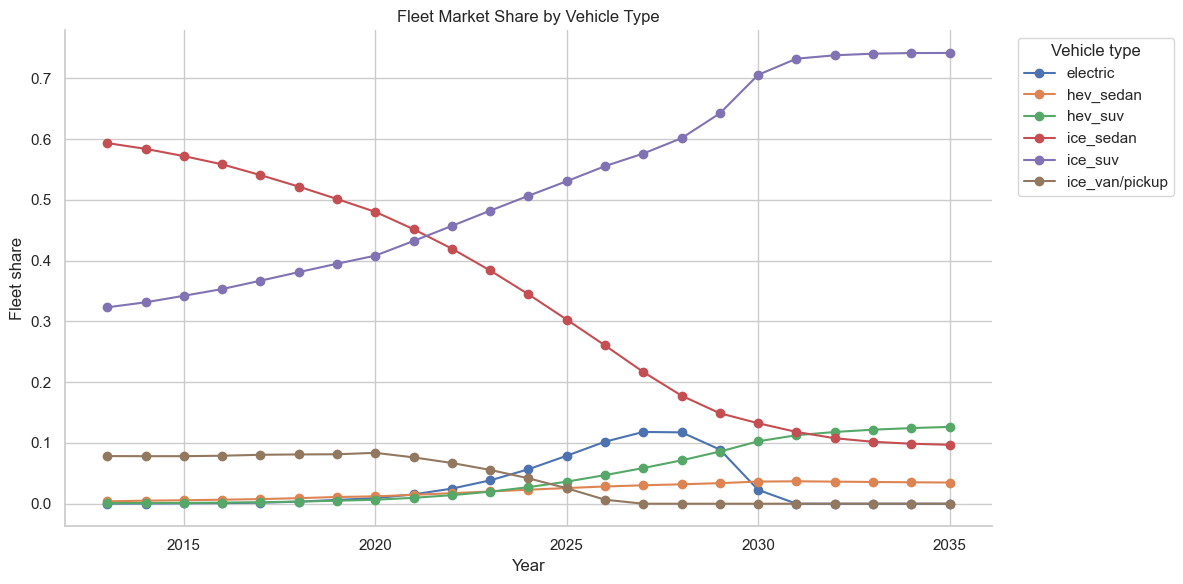

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
projected_market_share[vehicle_cols].plot(ax=ax, marker='o')
ax.set_title('Fleet Market Share by Vehicle Type')
ax.set_xlabel('Year')
ax.set_ylabel('Fleet share')
ax.legend(title='Vehicle type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Plot 5: Vehicle Counts by Type

This plot shows the fleet in absolute terms, not only percentages.

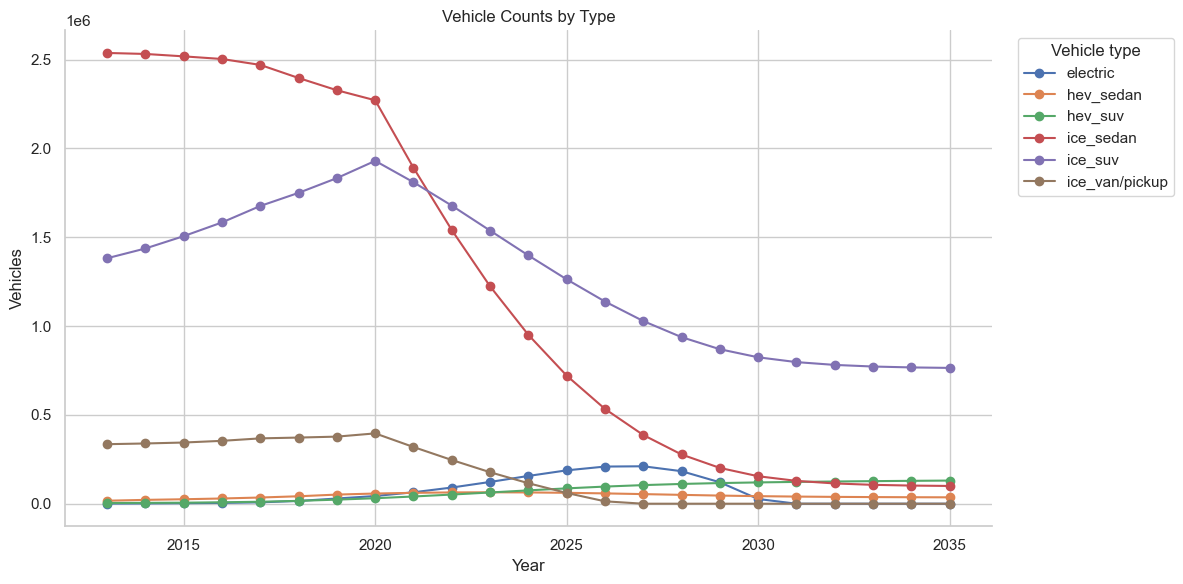

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
projected_counts[vehicle_cols].plot(ax=ax, marker='o')
ax.set_title('Vehicle Counts by Type')
ax.set_xlabel('Year')
ax.set_ylabel('Vehicles')
ax.legend(title='Vehicle type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Interpretation Notes

This model is stronger than the average-net-change version because:

- it treats entries and disposals as separate processes,
- it uses `Sortant` directly instead of inferring exits indirectly,
- it allows disposal composition to evolve by vehicle type.

Important caveats:

- if the historical `Sortant` series is noisy, disposal shares may still need smoothing,
- if the linear rate forecast becomes unrealistic, use the `average` option or clip the rates more aggressively,
- small vehicle categories may still need additional shrinkage.

## Optional: Save Outputs

This cell saves the main forecast tables to a dedicated folder.

In [21]:
output_dir = PROJECT_DIR / 'validation_outputs' / 'replacement_dynamics_entry_exit_model'
output_dir.mkdir(parents=True, exist_ok=True)

projection_summary.to_csv(output_dir / 'projection_summary.csv', index=False)
projected_counts.to_csv(output_dir / 'projected_counts.csv')
projected_market_share.to_csv(output_dir / 'projected_market_share.csv')
flow_forecast.to_csv(output_dir / 'flow_forecast.csv')
entry_share_future.to_csv(output_dir / 'entry_share_future.csv')
exit_share_future.to_csv(output_dir / 'exit_share_future.csv')

output_dir

PosixPath('/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model/validation_outputs/replacement_dynamics_entry_exit_model')